## 20251027 Numerical Bathtub

## 1. Model build-up

Let's consider solving the time-dependent regulator model numerically. We start with writing down the set of ODEs and note that I replace all the parameters into surface density to describe the spatially-resolved scenario.

First, as usual, we define the SFR surface density in two ways: 
$$
\begin{split}
\Sigma_\mathrm{SFR}[t] = \epsilon[t]\Sigma_\mathrm{g}[t] = \frac{d}{dt}\Sigma_*[t]
\end{split}
$$
Then, the change of gas mass surface density:
$$
\begin{split}
\frac{d}{dt}\Sigma_\mathrm{g}[t] = \Sigma_\mathrm{in}[t]-(1-R+\lambda)\epsilon[t]\Sigma_\mathrm{g}[t]
\end{split}
$$
Next, the change of metal mass surface density:
$$
\begin{split}
\frac{d}{dt}\Sigma_Z[t] = y(1-R)\epsilon[t]\Sigma_\mathrm{g}[t]-(1-R+\lambda)\epsilon[t]\Sigma_\mathrm{g}[t]Z[t]+\Sigma_\mathrm{in}[t]Z_\mathrm{in}
\end{split}
$$
And, we also define the metallicity as:
$$
\begin{split}
Z[t]=\frac{\Sigma_Z[t]}{\Sigma_\mathrm{g}[t]}
\end{split}
$$
Also, the sSFR:
$$
\begin{split}
\mathrm{sSFR} = \frac{\Sigma_\mathrm{SFR}}{\Sigma_*}
\end{split}
$$
Finally, we can convert metallicity to observable with solar abundace at 8.69 (Asplund+2021):
$$
\begin{split}
12+\log_{10}(\mathrm{O/H})[t] = 8.69+\log_{10}(Z[t])
\end{split}
$$

## 2. Equilibrium state

Taking the product rule of Eq. 3 and substituting Eq.1 to it, we get $\frac{dZ[t]}{dt}$
$$
Z[t](\Sigma_\mathrm{in}[t] - (1-R+\lambda)\Sigma_\mathrm{SFR}[t])+\Sigma_\mathrm{g}[t]\frac{dZ[t]}{dt} = y(1-R)\Sigma_\mathrm{SFR}[t]-Z[t](1-R+\lambda)\Sigma_\mathrm{SFR}[t]+Z_\mathrm{in}\Sigma_\mathrm{in}[t] \\
\Sigma_\mathrm{g}[t]\frac{dZ[t]}{dt} = y(1-R)\Sigma_\mathrm{SFR}[t]+(Z_\mathrm{in}-Z[t])\Sigma_\mathrm{in}[t] \\
\frac{dZ[t]}{dt} = \frac{1}{\Sigma_\mathrm{g}[t]}(y(1-R)\Sigma_\mathrm{SFR}[t]+(Z_\mathrm{in}-Z[t])\Sigma_\mathrm{in}[t]) \\
$$
Now let's consider the equilibrium state that the model rapidly self-regulates to a steady state, which means $\frac{dZ[t]}{dt} = 0$ in a short time scale (compared to the total depletion time). Thus, such metallicity at equilibrium state ($Z_\mathrm{eq}$) are a series of constant that is time-independent in a short period of time (but it is still time-dependent in a much longer period, so it is still written as $Z_\mathrm{eq}[t]$). And therefore it requires
$$
\begin{split}
\frac{dZ[t]}{dt} = \frac{1}{\Sigma_\mathrm{g}[t]}(y(1-R)\Sigma_\mathrm{SFR}[t]+(Z_\mathrm{in}-Z_\mathrm{eq}[t])\Sigma_\mathrm{in}[t]) = 0 \\
y(1-R)\Sigma_\mathrm{SFR}[t]+(Z_\mathrm{in}-Z_\mathrm{eq}[t])\Sigma_\mathrm{in}[t] = 0 \\
Z_\mathrm{eq}[t] = Z_\mathrm{in} + y(1-R)\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]} \\
\end{split}
$$
Again, we are interested in the metallicity that satisfy $Z[t] = Z_\mathrm{in} + y(1-R)\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]}$, at any given $t$. 

Thus, with this set of $Z_\mathrm{eq}$, we can find the mean value ($<Z_\mathrm{eq}>$) and then consider a small perdubation (offset from $<Z_\mathrm{eq}>$). Since $y$ and $R$ are all constant here, we have 
$$
\begin{split}
\delta Z_\mathrm{eq}[t] = y(1-R)\delta(\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]})  \\
\end{split}
$$
 Because we are interested in the offest in $12+\log_{10}(\mathrm{O/H})$, we have
$$
\begin{split}
\delta(12+\log_{10}(\mathrm{O/H})_\mathrm{eq}[t]) &= \delta\log_{10}(Z_\mathrm{eq}[t])  \\
&= \frac{1}{\ln10}\frac{\delta Z_\mathrm{eq}[t]}{Z_\mathrm{eq}[t]} \\
&= \frac{1}{\ln10}\frac{y(1-R)\delta(\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]})}{Z_\mathrm{in}+y(1-R)\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]}} \\
&= \frac{y(1-R)\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]}}{Z_\mathrm{in}+y(1-R)\frac{\Sigma_\mathrm{SFR}[t]}{\Sigma_\mathrm{in}[t]}}(\delta\log_{10}(\Sigma_\mathrm{SFR}[t])-\delta\log_{10}(\Sigma_\mathrm{in}[t])) \\
&= \frac{Z_\mathrm{eq}[t]-Z_\mathrm{in}}{Z_\mathrm{eq}[t]}(\delta\log_{10}(\Sigma_\mathrm{SFR}[t])-\delta\log_{10}(\Sigma_\mathrm{in}[t])) \\
&\propto \delta\log_{10}(\Sigma_\mathrm{SFR}[t])-\delta\log_{10}(\Sigma_\mathrm{in}[t]) \\
\end{split} \\
$$
Thus, we can see that the sign of $\delta(12+\log_{10}(\mathrm{O/H})_\mathrm{eq})$ is only dertermined by relative change of $\log_{10}(\Sigma_\mathrm{SFR}[t])$ and $\log_{10}(\Sigma_\mathrm{in}[t])$. 

More specific, by $\Sigma_\mathrm{SFR}[t]=\epsilon[t]\Sigma_\mathrm{g}[t]$, where $\epsilon[t]$ is the star formation efficiency, we have 
$$
\begin{split}
\delta(12+\log_{10}(\mathrm{O/H})_\mathrm{eq}) \propto \delta\log_{10}(\epsilon[t])+\delta\log_{10}(\Sigma_\mathrm{g}[t])-\delta\log_{10}(\Sigma_\mathrm{in}[t])  \\ 
\end{split}
$$
Therefore, this leaves us 3 cases. Note that $\delta$ in $\log$ scale of a quantity indicates the relative change of the quantity, and the sign indicates increase or decrease. 

1. In the case that $\delta\log_{10}(\epsilon[t])$ dominants, if $\delta\log_{10}(\epsilon[t])$ increases, both $\delta(12+\log_{10}(\mathrm{O/H})_\mathrm{eq})$ and $\delta\log_{10}(\Sigma_\mathrm{SFR}[t])$ increase immediately, so we can observe the positive correlation between them. 
2. However, if $\delta\log_{10}(\Sigma_\mathrm{in}[t])$ dominates, even though $\delta\log_{10}(\Sigma_\mathrm{SFR}[t])$ is still positive, due to the minus sign and relatively large change in $\delta\log_{10}(\Phi[t])$, we can observe negative correlation. 
3. If the change of $\log_{10}(\Sigma_\mathrm{SFR}[t])$ and $\log_{10}(\Sigma_\mathrm{in}[t])$ is comparable, that lead to nearly stationary $12+\log_{10}(\mathrm{O/H})$, which show no correlation. In this scenario, it requires $\Phi[t]$ is linearly proportional to $\mathrm{SFR}[t]$. 

## 3. Constants and initial values

Here, return fraction, metal yield per stellar, mass loading factor and inflow metallicity are constants:
$$
\left\{
\begin{split}
R &= 0.5 \\
y &= 0.01 \\
\lambda &= 1.5 \\
Z_\mathrm{in} &= 0.1 \\
\end{split}
\right.
$$
Now let's say at $t=0\mathrm{yr}$,  we have 
$$
\left\{
\begin{split}
\epsilon_0 &= \epsilon[t=0] = \frac{\Sigma_\mathrm{SFR,0}}{\Sigma_\mathrm{g,0}} = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in,0} &= \Sigma_\mathrm{in}[t=0] = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
Z_0 &= Z[t=0] = 0.5 \\
\Sigma_{*,0} &= \Sigma_*[t=0] = 10^7\mathrm{M_\odot/kpc^2} \\
\Sigma_\mathrm{g,0} &= \Sigma_\mathrm{g}[t=0] = 10^6\mathrm{M_\odot/kpc^2} \\
\Sigma_\mathrm{SFR,0} &= \Sigma_\mathrm{SFR}[t=0] = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\mathrm{sSFR}_0 &= \mathrm{sSFR}[t=0] = \frac{\Sigma_\mathrm{SFR,0}}{\Sigma_{*,0}} = 10^{-10}/\mathrm{yr} \\
\Sigma_{Z,0} &= \Sigma_{Z}[t=0] = \Sigma_\mathrm{in,0}\Sigma_{Z,0} = 0.5\times10^6\mathrm{M_\odot/kpc^2} \\
12+\log_{10}(\mathrm{O/H})_0 &= 12+\log_{10}(\mathrm{O/H})[t=0] = 8.69+\log_{10}(Z_0) \\
\end{split}
\right.
$$

## 4. Numerical forms of $\epsilon[t]$ and $\Sigma_\mathrm{in}[t]$

We consider the following cases:

### 4.1 Constant $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

A simple case that both are constant:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\end{split}
\right.
$$

### 4.2 Sinusoidal variation of $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

Here we define a constant $A=0.1$ here to denote the amplitide of the sinusoidal variation compared to initial value, and $T_p = 1000$ (in the unit of yr) to indicate the variation period:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 + A\epsilon_0\sin(\frac{2\pi t}{T_p}) \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\end{split}
\right.
$$

### 4.3 Constant $\epsilon[t]$ and sinusoidal variation of $\Sigma_\mathrm{in}[t]$

Similarly, we have:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} + A\Sigma_\mathrm{in,0}\sin(\frac{2\pi t}{T_p}) \\
\end{split}
\right.
$$

## 5. Evolution

We consider a total period of $T = 10\mathrm{Gyr}$, with a timestep of $\Delta t = 0.1\mathrm{yr}$. Thus, for any given moment $t_i \in [0,T]$, the iteration in the next timestamp ($t_{i+1} = t_i+\Delta t$) will be 
$$
\left\{
\begin{split}
\epsilon[t_{i+1}] &= \epsilon[t_{i+1}] \\
\Sigma_\mathrm{in}[t_{i+1}] &= \Sigma_\mathrm{in}[t_{i+1}] \\
\Sigma_\mathrm{g}[t_{i+1}] &= \Sigma_\mathrm{g}[t_i]+\frac{d}{dt}\Sigma_\mathrm{g}[t_i]\Delta t \\ 
&= \Sigma_\mathrm{g}[t_i]+(\Sigma_\mathrm{in}[t_i]-(1-R+\lambda)\epsilon[t_i]\Sigma_\mathrm{g}[t_i])\Delta t \\
\Sigma_Z[t_{i+1}] &= \Sigma_\mathrm{Z}[t_i]+\frac{d}{dt}\Sigma_\mathrm{Z}[t_i]\Delta t \\ 
&= \Sigma_\mathrm{Z}[t_i]+(y(1-R)\epsilon[t_i]\Sigma_\mathrm{g}[t_i]-(1-R+\lambda)\epsilon[t_i]\Sigma_\mathrm{g}[t_i]Z[t_i]+\Sigma_\mathrm{in}[t_i]Z_\mathrm{in})\Delta t \\ 
\Sigma_\mathrm{SFR}[t_{i+1}] &= \epsilon[t_{i+1}]\Sigma_\mathrm{g}[t_{i+1}] \\
Z[t_{i+1}] &= \frac{\Sigma_Z[t_{i+1}]}{\Sigma_\mathrm{g}[t_{i+1}]} \\
\Sigma_*[t_{i+1}] &= \Sigma_*[t_{i}]+\Sigma_\mathrm{SFR}[t_i]\Delta t \\
\mathrm{sSFR}[t_{i+1}] &= \frac{\Sigma_\mathrm{SFR}[t_{i+1}]}{\Sigma_*[t_{i+1}]} \\
12+\log_{10}(\mathrm{O/H})[t_{i+1}] &= 8.69+\log_{10}(Z[t_{i+1}]) \\
\end{split}
\right.
$$



In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
## Global parameters
T = 10000e6  # yr (total evolution time)
dt = 0.1e6   # yr (timestep)

In [27]:
## Local parameters
R = 0.5          # Return fraction
y = 0.1         # Metal yield per stellar generation
lmbda = 1.5      # Mass loading factor (using lmbda instead of lambda to avoid keyword)
Z_in = 1       # Z_sol (inflow metallicity)

In [28]:
## Sinusoidal variation parameters
A = 0.1       # Amplitude of sinusoidal variation for epsilon (fraction of initial value)
T_p = 1000e6  # yr (period of sinusoidal variation)

In [29]:
## Initial values at t=0
epsilon_0 = 1e-8            # 1/yr (star formation efficiency)
Sigma_in_0 = 1e-3           # M_sol/yr/kpc^2 (inflow rate surface density)
Sigma_star_0 = 1e7          # M_sol/kpc^2 (stellar surface density)
Sigma_g_0 = Sigma_in_0/((1-R+lmbda)*epsilon_0)           # M_sol/kpc^2 (gas surface density)
Sigma_SFR_0 = epsilon_0 * Sigma_g_0          # M_sol/yr/kpc^2 (SFR surface density)
sSFR_0 = Sigma_SFR_0 / Sigma_star_0  # 1/yr (specific SFR)
Z_0 = Z_in + y*(1-R) * Sigma_SFR_0 / Sigma_in_0                    # Z_sol (initial metallicity)
Sigma_Z_0 = Z_0 * Sigma_g_0          # M_sol/kpc^2 (metal surface density)
OH_0 = 8.69 + np.log10(Z_0)  # 12 + log10(O/H) (oxygen abundance)

# Additional derived quantities
log10_Sigma_SFR_0 = np.log10(Sigma_SFR_0)  # log10(M_sol/yr/kpc^2)
log10_Sigma_star_0 = np.log10(Sigma_star_0)  # log10(M_sol/kpc^2)
log10_sSFR_0 = np.log10(sSFR_0)  # log10(1/yr)
Z_eq_0 = Z_in + y * (1 - R) * Sigma_SFR_0 / Sigma_in_0  # Z_sol (equilibrium metallicity)

print(f"Star formation efficiency at t=0: {epsilon_0} 1/yr ")
print(f"Inflow rate surface density at t=0: {Sigma_in_0} M_sol/yr/kpc^2 ")
print(f"Initial metallicity at t=0: {Z_0} Z_sol ")
print(f"Stellar surface density at t=0: {Sigma_star_0} M_sol/kpc^2 ")
print(f"Gas surface density at t=0: {Sigma_g_0} M_sol/kpc^2 ")
print(f"SFR surface density at t=0: {Sigma_SFR_0} M_sol/yr/kpc^2 ")
print(f"Specific SFR at t=0: {sSFR_0} 1/yr ")
print(f"Metal surface density at t=0: {Sigma_Z_0} M_sol/kpc^2 ")
print(f"Metallicity at t=0: {Z_0} Z_sol")
print(f"Oxygen abundance at t=0: {OH_0} ")
print(f"log10(Sigma_SFR) at t=0: {log10_Sigma_SFR_0} ")
print(f"log10(Sigma_star) at t=0: {log10_Sigma_star_0} ")
print(f"log10(sSFR) at t=0: {log10_sSFR_0} ")
print(f"Equilibrium metallicity at t=0: {Z_eq_0} Z_sol ")

Star formation efficiency at t=0: 1e-08 1/yr 
Inflow rate surface density at t=0: 0.001 M_sol/yr/kpc^2 
Initial metallicity at t=0: 1.025 Z_sol 
Stellar surface density at t=0: 10000000.0 M_sol/kpc^2 
Gas surface density at t=0: 50000.0 M_sol/kpc^2 
SFR surface density at t=0: 0.0005 M_sol/yr/kpc^2 
Specific SFR at t=0: 5e-11 1/yr 
Metal surface density at t=0: 51249.99999999999 M_sol/kpc^2 
Metallicity at t=0: 1.025 Z_sol
Oxygen abundance at t=0: 8.700723865391772 
log10(Sigma_SFR) at t=0: -3.3010299956639813 
log10(Sigma_star) at t=0: 7.0 
log10(sSFR) at t=0: -10.301029995663981 
Equilibrium metallicity at t=0: 1.025 Z_sol 


In [30]:
## Define evolution function
def run_evolution(epsilon_type='const', Sigma_in_type='const'):
    """
    Run the time evolution for given epsilon and Sigma_in types.
    
    Parameters:
    -----------
    epsilon_type : str
        'const' for constant epsilon, 'sin' for sinusoidal variation
    Sigma_in_type : str
        'const' for constant Sigma_in, 'sin' for sinusoidal variation
    
    Returns:
    --------
    dict : Dictionary containing all evolution arrays with appropriate names
    """
    
    # Number of timesteps
    n_steps = int(T / dt)
    
    # Initialize arrays to store evolution
    t_array = np.zeros(n_steps + 1)
    epsilon_array = np.zeros(n_steps + 1)
    Sigma_in_array = np.zeros(n_steps + 1)
    Sigma_g_array = np.zeros(n_steps + 1)
    Sigma_Z_array = np.zeros(n_steps + 1)
    Sigma_SFR_array = np.zeros(n_steps + 1)
    Z_array = np.zeros(n_steps + 1)
    Sigma_star_array = np.zeros(n_steps + 1)
    sSFR_array = np.zeros(n_steps + 1)
    OH_array = np.zeros(n_steps + 1)
    log10_Sigma_SFR_array = np.zeros(n_steps + 1)
    log10_Sigma_star_array = np.zeros(n_steps + 1)
    log10_sSFR_array = np.zeros(n_steps + 1)
    Z_eq_array = np.zeros(n_steps + 1)
    
    # Set initial conditions (i=0)
    t_array[0] = 0
    epsilon_array[0] = epsilon_0
    Sigma_in_array[0] = Sigma_in_0
    Sigma_g_array[0] = Sigma_g_0
    Sigma_Z_array[0] = Sigma_Z_0
    Sigma_SFR_array[0] = Sigma_SFR_0
    Z_array[0] = Z_0
    Sigma_star_array[0] = Sigma_star_0
    sSFR_array[0] = sSFR_0
    OH_array[0] = OH_0
    log10_Sigma_SFR_array[0] = log10_Sigma_SFR_0
    log10_Sigma_star_array[0] = log10_Sigma_star_0
    log10_sSFR_array[0] = log10_sSFR_0
    Z_eq_array[0] = Z_eq_0
    
    # Time evolution loop
    for i in range(n_steps):
        # Current time
        t_i = t_array[i]
        
        # Update time for next step FIRST (needed for sin calculations)
        t_array[i+1] = t_i + dt
        
        # Update epsilon[t_{i+1}] based on type
        if epsilon_type == 'const':
            # Case 4.1 or 4.3: epsilon[t] = epsilon_0
            epsilon_array[i+1] = epsilon_0
        elif epsilon_type == 'sin':
            # Case 4.2: epsilon[t] = epsilon_0 * (1 + A*sin(2*pi*t/T_p))
            epsilon_array[i+1] = epsilon_0 * (1 + A * np.sin(2 * np.pi * t_array[i+1] / T_p))
        
        # Update Sigma_in[t_{i+1}] based on type
        if Sigma_in_type == 'const':
            # Case 4.1 or 4.2: Sigma_in[t] = Sigma_in_0
            Sigma_in_array[i+1] = Sigma_in_0
        elif Sigma_in_type == 'sin':
            # Case 4.3: Sigma_in[t] = Sigma_in_0 * (1 + A*sin(2*pi*t/T_p))
            Sigma_in_array[i+1] = Sigma_in_0 * (1 + A * np.sin(2 * np.pi * t_array[i+1] / T_p))
        
        # Update gas surface density
        # Sigma_g[t_{i+1}] = Sigma_g[t_i] + (Sigma_in[t_i] - (1-R+lambda)*epsilon[t_i]*Sigma_g[t_i]) * dt
        dSigma_g_dt = Sigma_in_array[i] - (1 - R + lmbda) * epsilon_array[i] * Sigma_g_array[i]
        Sigma_g_array[i+1] = Sigma_g_array[i] + dSigma_g_dt * dt
        
        # Update metal surface density
        # Sigma_Z[t_{i+1}] = Sigma_Z[t_i] + (y*(1-R)*epsilon[t_i]*Sigma_g[t_i] - (1-R+lambda)*epsilon[t_i]*Sigma_g[t_i]*Z[t_i] + Sigma_in[t_i]*Z_in) * dt
        dSigma_Z_dt = (y * (1 - R) * epsilon_array[i] * Sigma_g_array[i] 
                       - (1 - R + lmbda) * epsilon_array[i] * Sigma_g_array[i] * Z_array[i] 
                       + Sigma_in_array[i] * Z_in)
        Sigma_Z_array[i+1] = Sigma_Z_array[i] + dSigma_Z_dt * dt
        
        # Update SFR surface density
        # Sigma_SFR[t_{i+1}] = epsilon[t_{i+1}] * Sigma_g[t_{i+1}]
        Sigma_SFR_array[i+1] = epsilon_array[i+1] * Sigma_g_array[i+1]
        
        # Update metallicity
        # Z[t_{i+1}] = Sigma_Z[t_{i+1}] / Sigma_g[t_{i+1}]
        Z_array[i+1] = Sigma_Z_array[i+1] / Sigma_g_array[i+1]
        
        # Update stellar surface density
        # Sigma_*[t_{i+1}] = Sigma_*[t_i] + Sigma_SFR[t_i] * dt
        Sigma_star_array[i+1] = Sigma_star_array[i] + Sigma_SFR_array[i] * dt
        
        # Update sSFR
        # sSFR[t_{i+1}] = Sigma_SFR[t_{i+1}] / Sigma_*[t_{i+1}]
        sSFR_array[i+1] = Sigma_SFR_array[i+1] / Sigma_star_array[i+1]
        
        # Update oxygen abundance
        # 12 + log10(O/H)[t_{i+1}] = 8.69 + log10(Z[t_{i+1}])
        OH_array[i+1] = 8.69 + np.log10(Z_array[i+1])
        
        # Update additional derived quantities
        # log10(Sigma_SFR[t_{i+1}])
        log10_Sigma_SFR_array[i+1] = np.log10(Sigma_SFR_array[i+1])
        
        # log10(Sigma_*[t_{i+1}])
        log10_Sigma_star_array[i+1] = np.log10(Sigma_star_array[i+1])
        
        # log10(sSFR[t_{i+1}])
        log10_sSFR_array[i+1] = np.log10(sSFR_array[i+1])
        
        # Z_eq[t_{i+1}] = Z_in + y*(1-R)*Sigma_SFR[t_{i+1}]/Sigma_in[t_{i+1}]
        Z_eq_array[i+1] = Z_in + y * (1 - R) * Sigma_SFR_array[i+1] / Sigma_in_array[i+1]
    
    # Find intersections between Z and Z_eq (equilibrium states)
    # Calculate difference Z - Z_eq
    diff = Z_array - Z_eq_array
    
    # Find sign changes (where intersection occurs)
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    
    # Lists to store equilibrium state parameters
    t_eq_list = []
    epsilon_eq_list = []
    Sigma_in_eq_list = []
    Sigma_g_eq_list = []
    Sigma_Z_eq_list = []
    Sigma_SFR_eq_list = []
    Z_eq_list = []
    Sigma_star_eq_list = []
    sSFR_eq_list = []
    OH_eq_list = []
    log10_Sigma_SFR_eq_list = []
    log10_Sigma_star_eq_list = []
    log10_sSFR_eq_list = []
    
    # For each intersection, interpolate to find precise equilibrium values
    for idx in sign_changes:
        t1, t2 = t_array[idx], t_array[idx+1]
        diff1, diff2 = diff[idx], diff[idx+1]
        
        # Linear interpolation to find intersection time
        if diff2 != diff1:
            t_intersect = t1 - diff1 * (t2 - t1) / (diff2 - diff1)
            weight = (t_intersect - t1) / (t2 - t1)
        else:
            t_intersect = (t1 + t2) / 2
            weight = 0.5
        
        # Interpolate all parameters at intersection time
        t_eq_list.append(t_intersect)
        epsilon_eq_list.append(epsilon_array[idx] + weight * (epsilon_array[idx+1] - epsilon_array[idx]))
        Sigma_in_eq_list.append(Sigma_in_array[idx] + weight * (Sigma_in_array[idx+1] - Sigma_in_array[idx]))
        Sigma_g_eq_list.append(Sigma_g_array[idx] + weight * (Sigma_g_array[idx+1] - Sigma_g_array[idx]))
        Sigma_Z_eq_list.append(Sigma_Z_array[idx] + weight * (Sigma_Z_array[idx+1] - Sigma_Z_array[idx]))
        Sigma_SFR_eq_list.append(Sigma_SFR_array[idx] + weight * (Sigma_SFR_array[idx+1] - Sigma_SFR_array[idx]))
        Z_eq_list.append(Z_array[idx] + weight * (Z_array[idx+1] - Z_array[idx]))
        Sigma_star_eq_list.append(Sigma_star_array[idx] + weight * (Sigma_star_array[idx+1] - Sigma_star_array[idx]))
        sSFR_eq_list.append(sSFR_array[idx] + weight * (sSFR_array[idx+1] - sSFR_array[idx]))
        OH_eq_list.append(OH_array[idx] + weight * (OH_array[idx+1] - OH_array[idx]))
        log10_Sigma_SFR_eq_list.append(log10_Sigma_SFR_array[idx] + weight * (log10_Sigma_SFR_array[idx+1] - log10_Sigma_SFR_array[idx]))
        log10_Sigma_star_eq_list.append(log10_Sigma_star_array[idx] + weight * (log10_Sigma_star_array[idx+1] - log10_Sigma_star_array[idx]))
        log10_sSFR_eq_list.append(log10_sSFR_array[idx] + weight * (log10_sSFR_array[idx+1] - log10_sSFR_array[idx]))
    
    # Convert lists to numpy arrays
    t_eq = np.array(t_eq_list)
    epsilon_eq = np.array(epsilon_eq_list)
    Sigma_in_eq = np.array(Sigma_in_eq_list)
    Sigma_g_eq = np.array(Sigma_g_eq_list)
    Sigma_Z_eq = np.array(Sigma_Z_eq_list)
    Sigma_SFR_eq = np.array(Sigma_SFR_eq_list)
    Z_eq_at_intersection = np.array(Z_eq_list)
    Sigma_star_eq = np.array(Sigma_star_eq_list)
    sSFR_eq = np.array(sSFR_eq_list)
    OH_eq = np.array(OH_eq_list)
    log10_Sigma_SFR_eq = np.array(log10_Sigma_SFR_eq_list)
    log10_Sigma_star_eq = np.array(log10_Sigma_star_eq_list)
    log10_sSFR_eq = np.array(log10_sSFR_eq_list)
    
    # Create suffix for array names
    suffix = f"{epsilon_type}_epsilon_{Sigma_in_type}_Sigma_in"
    
    # Store results in dictionary with appropriate names
    results = {
        f't_array_{suffix}': t_array,
        f'epsilon_array_{suffix}': epsilon_array,
        f'Sigma_in_array_{suffix}': Sigma_in_array,
        f'Sigma_g_array_{suffix}': Sigma_g_array,
        f'Sigma_Z_array_{suffix}': Sigma_Z_array,
        f'Sigma_SFR_array_{suffix}': Sigma_SFR_array,
        f'Z_array_{suffix}': Z_array,
        f'Sigma_star_array_{suffix}': Sigma_star_array,
        f'sSFR_array_{suffix}': sSFR_array,
        f'OH_array_{suffix}': OH_array,
        f'log10_Sigma_SFR_array_{suffix}': log10_Sigma_SFR_array,
        f'log10_Sigma_star_array_{suffix}': log10_Sigma_star_array,
        f'log10_sSFR_array_{suffix}': log10_sSFR_array,
        f'Z_eq_array_{suffix}': Z_eq_array,
        # Equilibrium intersection arrays
        f't_array_{suffix}_eq': t_eq,
        f'epsilon_array_{suffix}_eq': epsilon_eq,
        f'Sigma_in_array_{suffix}_eq': Sigma_in_eq,
        f'Sigma_g_array_{suffix}_eq': Sigma_g_eq,
        f'Sigma_Z_array_{suffix}_eq': Sigma_Z_eq,
        f'Sigma_SFR_array_{suffix}_eq': Sigma_SFR_eq,
        f'Z_array_{suffix}_eq': Z_eq_at_intersection,
        f'Sigma_star_array_{suffix}_eq': Sigma_star_eq,
        f'sSFR_array_{suffix}_eq': sSFR_eq,
        f'OH_array_{suffix}_eq': OH_eq,
        f'log10_Sigma_SFR_array_{suffix}_eq': log10_Sigma_SFR_eq,
        f'log10_Sigma_star_array_{suffix}_eq': log10_Sigma_star_eq,
        f'log10_sSFR_array_{suffix}_eq': log10_sSFR_eq
    }
    
    print(f"Evolution complete for epsilon={epsilon_type}, Sigma_in={Sigma_in_type}")
    print(f"  Total timesteps: {n_steps}")
    print(f"  Final time: {t_array[-1]} yr")
    print(f"  Found {len(t_eq)} equilibrium intersection points")
    if len(t_eq) > 1:
        print(f"  Average period between intersections: {np.mean(np.diff(t_eq)):.2f} yr")
    print(f"  Arrays saved with suffix: {suffix}")
    print(f"  Equilibrium arrays saved with suffix: {suffix}_eq")
    
    return results

print("Evolution function defined. Ready to run simulations.")

Evolution function defined. Ready to run simulations.


In [31]:
## Run all cases and store results in global namespace

# Case 4.1: Constant epsilon and constant Sigma_in
print("\n=== Case 4.1: Constant epsilon, Constant Sigma_in ===")
results_const_const = run_evolution(epsilon_type='const', Sigma_in_type='const')
# Unpack to global namespace
for key, value in results_const_const.items():
    globals()[key] = value

# Case 4.2: Sinusoidal epsilon and constant Sigma_in  
print("\n=== Case 4.2: Sinusoidal epsilon, Constant Sigma_in ===")
results_sin_const = run_evolution(epsilon_type='sin', Sigma_in_type='const')
# Unpack to global namespace
for key, value in results_sin_const.items():
    globals()[key] = value

# Case 4.3: Constant epsilon and sinusoidal Sigma_in
print("\n=== Case 4.3: Constant epsilon, Sinusoidal Sigma_in ===")
results_const_sin = run_evolution(epsilon_type='const', Sigma_in_type='sin')
# Unpack to global namespace
for key, value in results_const_sin.items():
    globals()[key] = value

# Case 4.4 (bonus): Sinusoidal epsilon and sinusoidal Sigma_in
print("\n=== Case 4.4 (Bonus): Sinusoidal epsilon, Sinusoidal Sigma_in ===")
results_sin_sin = run_evolution(epsilon_type='sin', Sigma_in_type='sin')
# Unpack to global namespace
for key, value in results_sin_sin.items():
    globals()[key] = value

print("\n" + "="*60)
print("All cases complete! Available arrays:")
print("="*60)
print("\nExample array names:")
print("  - OH_array_const_epsilon_const_Sigma_in")
print("  - OH_array_sin_epsilon_const_Sigma_in")
print("  - OH_array_const_epsilon_sin_Sigma_in")
print("  - OH_array_sin_epsilon_sin_Sigma_in")
print("\nAll parameters have corresponding arrays with these suffixes.")


=== Case 4.1: Constant epsilon, Constant Sigma_in ===
Evolution complete for epsilon=const, Sigma_in=const
  Total timesteps: 100000
  Final time: 10000000000.0 yr
  Found 0 equilibrium intersection points
  Arrays saved with suffix: const_epsilon_const_Sigma_in
  Equilibrium arrays saved with suffix: const_epsilon_const_Sigma_in_eq

=== Case 4.2: Sinusoidal epsilon, Constant Sigma_in ===
Evolution complete for epsilon=sin, Sigma_in=const
  Total timesteps: 100000
  Final time: 10000000000.0 yr
  Found 21 equilibrium intersection points
  Average period between intersections: 481022789.31 yr
  Arrays saved with suffix: sin_epsilon_const_Sigma_in
  Equilibrium arrays saved with suffix: sin_epsilon_const_Sigma_in_eq

=== Case 4.3: Constant epsilon, Sinusoidal Sigma_in ===
Evolution complete for epsilon=const, Sigma_in=sin
  Total timesteps: 100000
  Final time: 10000000000.0 yr
  Found 21 equilibrium intersection points
  Average period between intersections: 480565482.96 yr
  Arrays sa

## 20251028 Case 1: constant $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

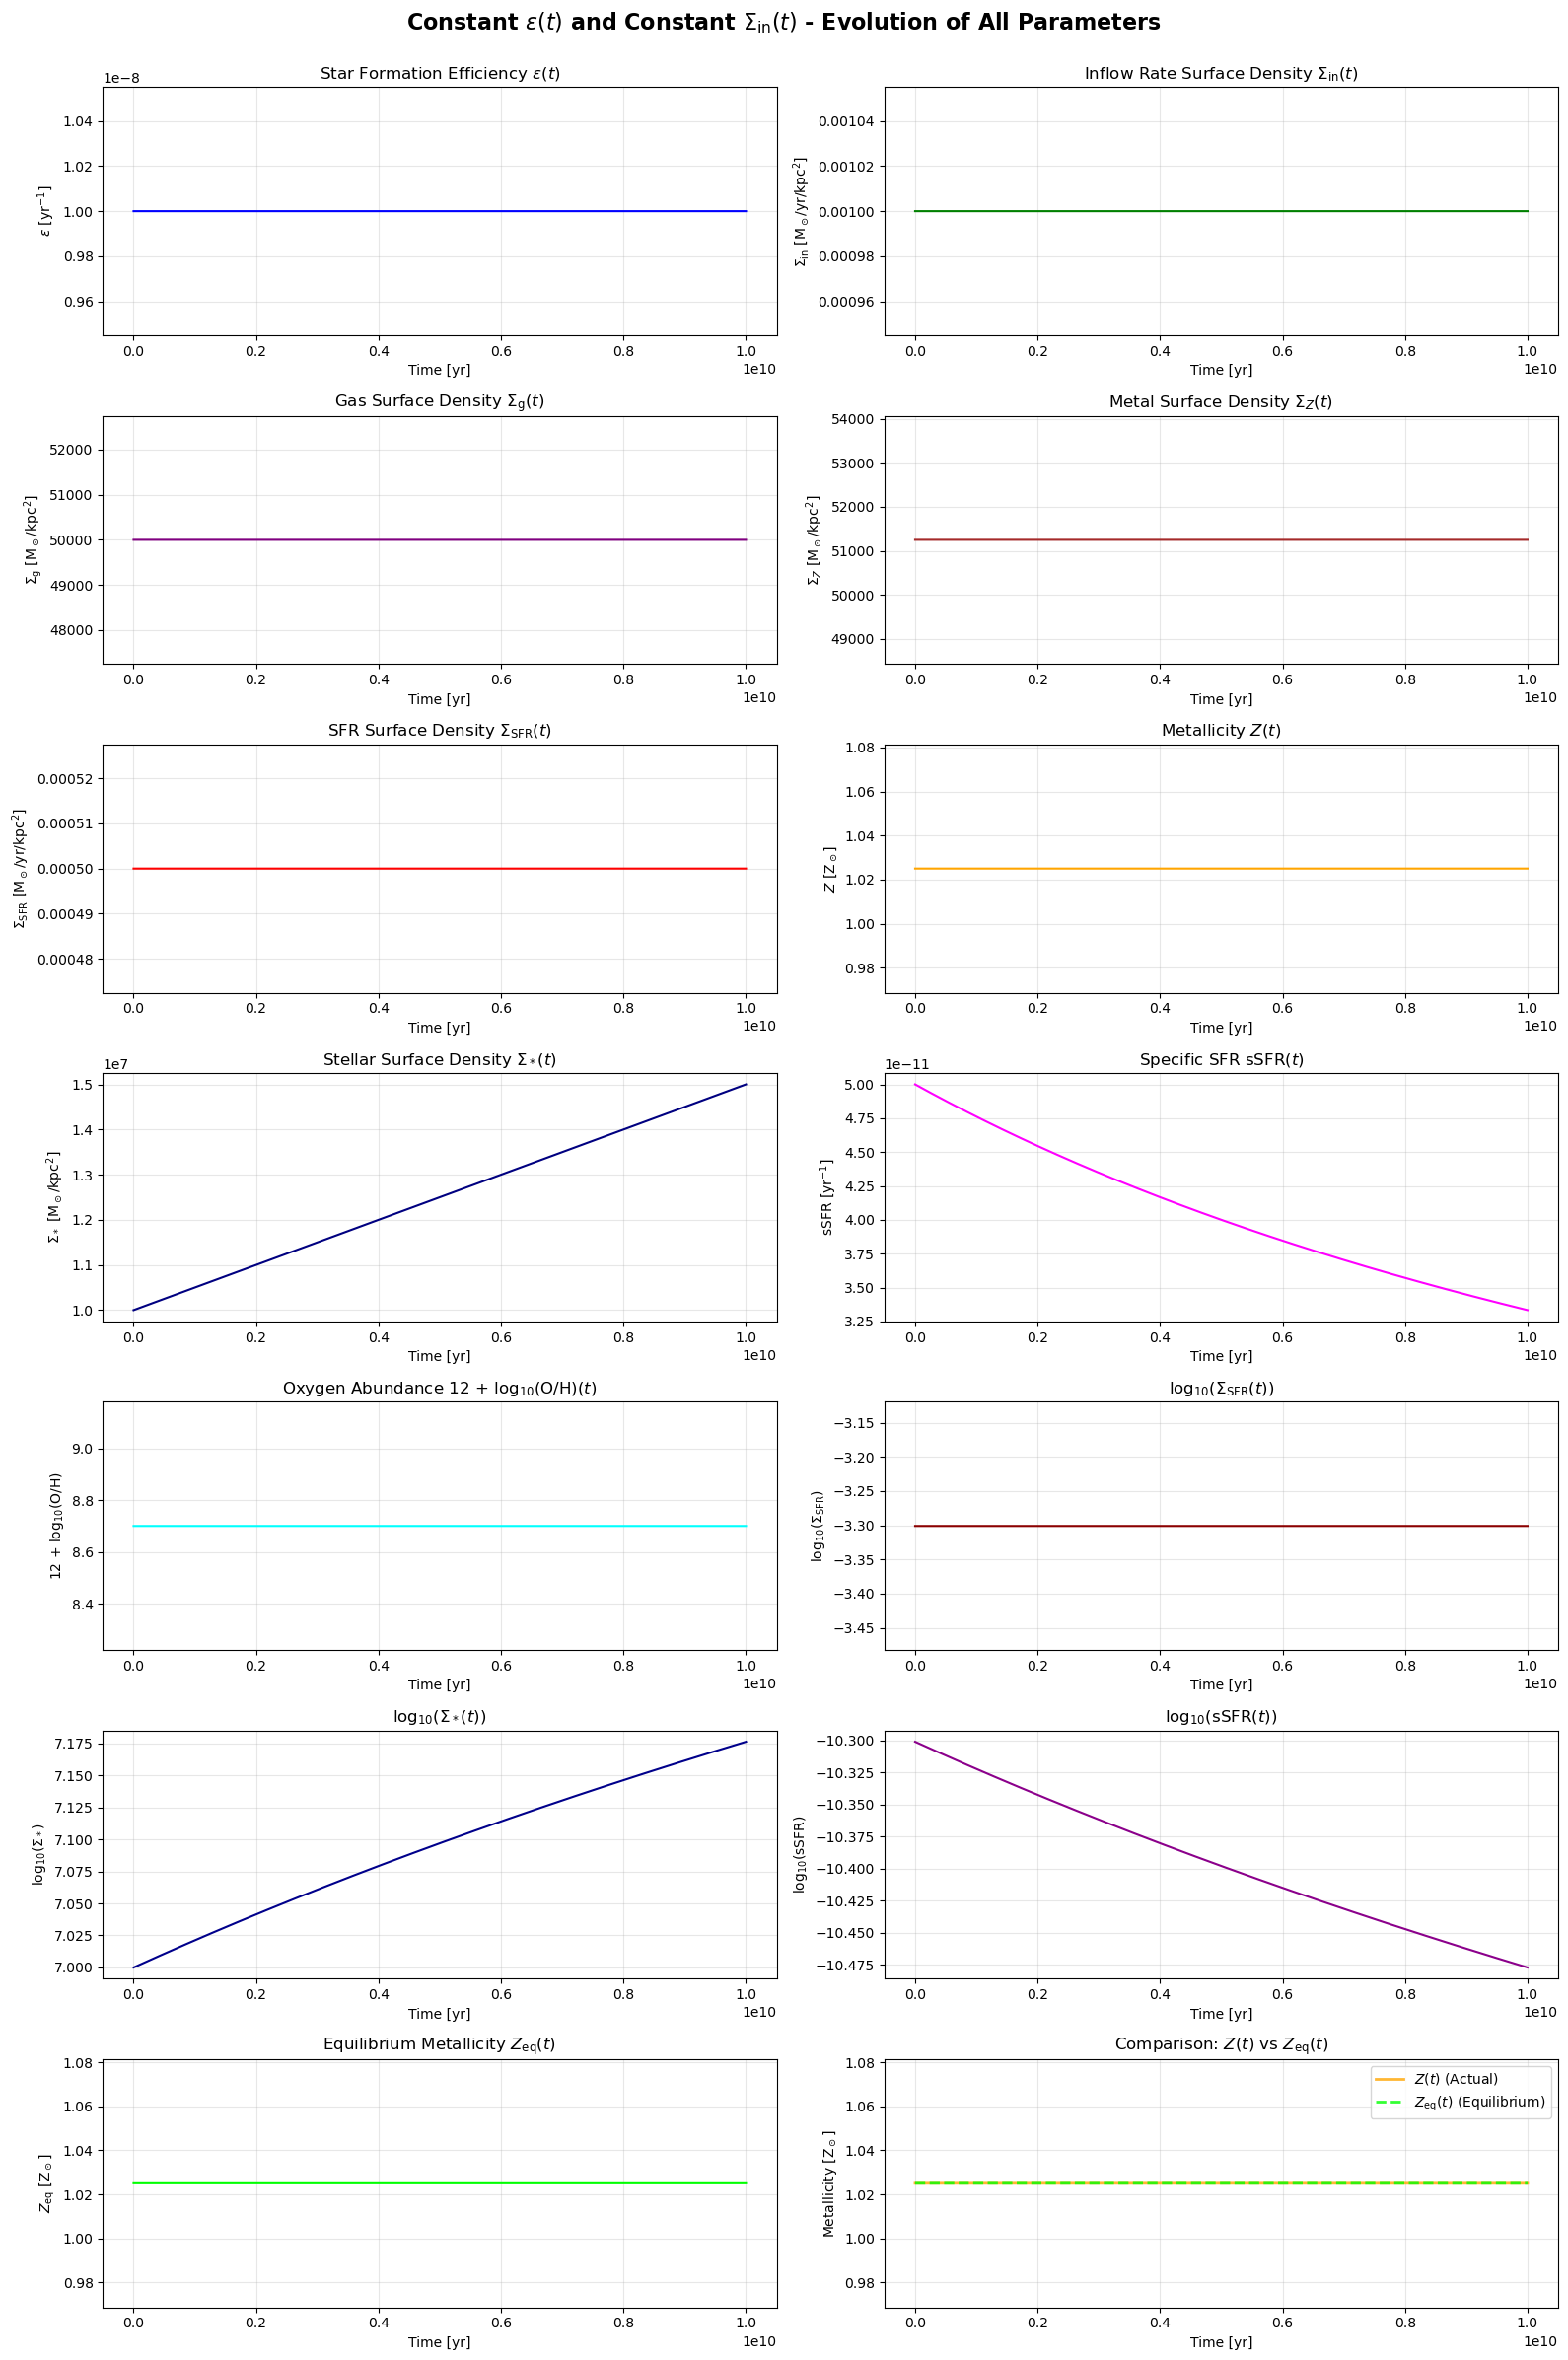


Summary of Case 4.1 evolution:
  Initial Z = 1.025000 Z_sol
  Final Z = 1.025000 Z_sol
  Initial Z_eq = 1.025000 Z_sol
  Final Z_eq = 1.025000 Z_sol
  Z converges to Z_eq: True


In [32]:
## Visualization of all 13 parameters evolution for Case that constant epsilon and constant Sigma_in

# Create figure with 14 subplots (7 rows x 2 columns)
fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

# Use the const_epsilon_const_Sigma_in arrays
t = t_array_const_epsilon_const_Sigma_in
epsilon = epsilon_array_const_epsilon_const_Sigma_in
Sigma_in = Sigma_in_array_const_epsilon_const_Sigma_in
Sigma_g = Sigma_g_array_const_epsilon_const_Sigma_in
Sigma_Z = Sigma_Z_array_const_epsilon_const_Sigma_in
Sigma_SFR = Sigma_SFR_array_const_epsilon_const_Sigma_in
Z = Z_array_const_epsilon_const_Sigma_in
Sigma_star = Sigma_star_array_const_epsilon_const_Sigma_in
sSFR = sSFR_array_const_epsilon_const_Sigma_in
OH = OH_array_const_epsilon_const_Sigma_in
log10_Sigma_SFR = log10_Sigma_SFR_array_const_epsilon_const_Sigma_in
log10_Sigma_star = log10_Sigma_star_array_const_epsilon_const_Sigma_in
log10_sSFR = log10_sSFR_array_const_epsilon_const_Sigma_in
Z_eq = Z_eq_array_const_epsilon_const_Sigma_in

# 1. epsilon[t]
axes[0].plot(t, epsilon, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t, Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t, Sigma_g, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t, Sigma_Z, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t, Sigma_SFR, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t, Z, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t, Sigma_star, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t, sSFR, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t, OH, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t, log10_Sigma_SFR, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t, log10_Sigma_star, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t, log10_sSFR, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# 13. Z_eq[t]
axes[12].plot(t, Z_eq, 'lime', linewidth=1.5)
axes[12].set_xlabel('Time [yr]')
axes[12].set_ylabel(r'$Z_{\rm eq}$ [Z$_\odot$]')
axes[12].set_title(r'Equilibrium Metallicity $Z_{\rm eq}(t)$')
axes[12].grid(True, alpha=0.3)

# 14. Z[t] vs Z_eq[t] comparison
axes[13].plot(t, Z, 'orange', linewidth=2, label=r'$Z(t)$ (Actual)', alpha=0.8)
axes[13].plot(t, Z_eq, 'lime', linewidth=2, label=r'$Z_{\rm eq}(t)$ (Equilibrium)', alpha=0.8, linestyle='--')
axes[13].set_xlabel('Time [yr]')
axes[13].set_ylabel(r'Metallicity [Z$_\odot$]')
axes[13].set_title(r'Comparison: $Z(t)$ vs $Z_{\rm eq}(t)$')
axes[13].legend(loc='best')
axes[13].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Constant $\\epsilon(t)$ and Constant $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 4.1 evolution:")
print(f"  Initial Z = {Z[0]:.6f} Z_sol")
print(f"  Final Z = {Z[-1]:.6f} Z_sol")
print(f"  Initial Z_eq = {Z_eq[0]:.6f} Z_sol")
print(f"  Final Z_eq = {Z_eq[-1]:.6f} Z_sol")
print(f"  Z converges to Z_eq: {np.abs(Z[-1] - Z_eq[-1]) < 0.001}")

## 20251028 Case 2: sinusoidal variation of $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

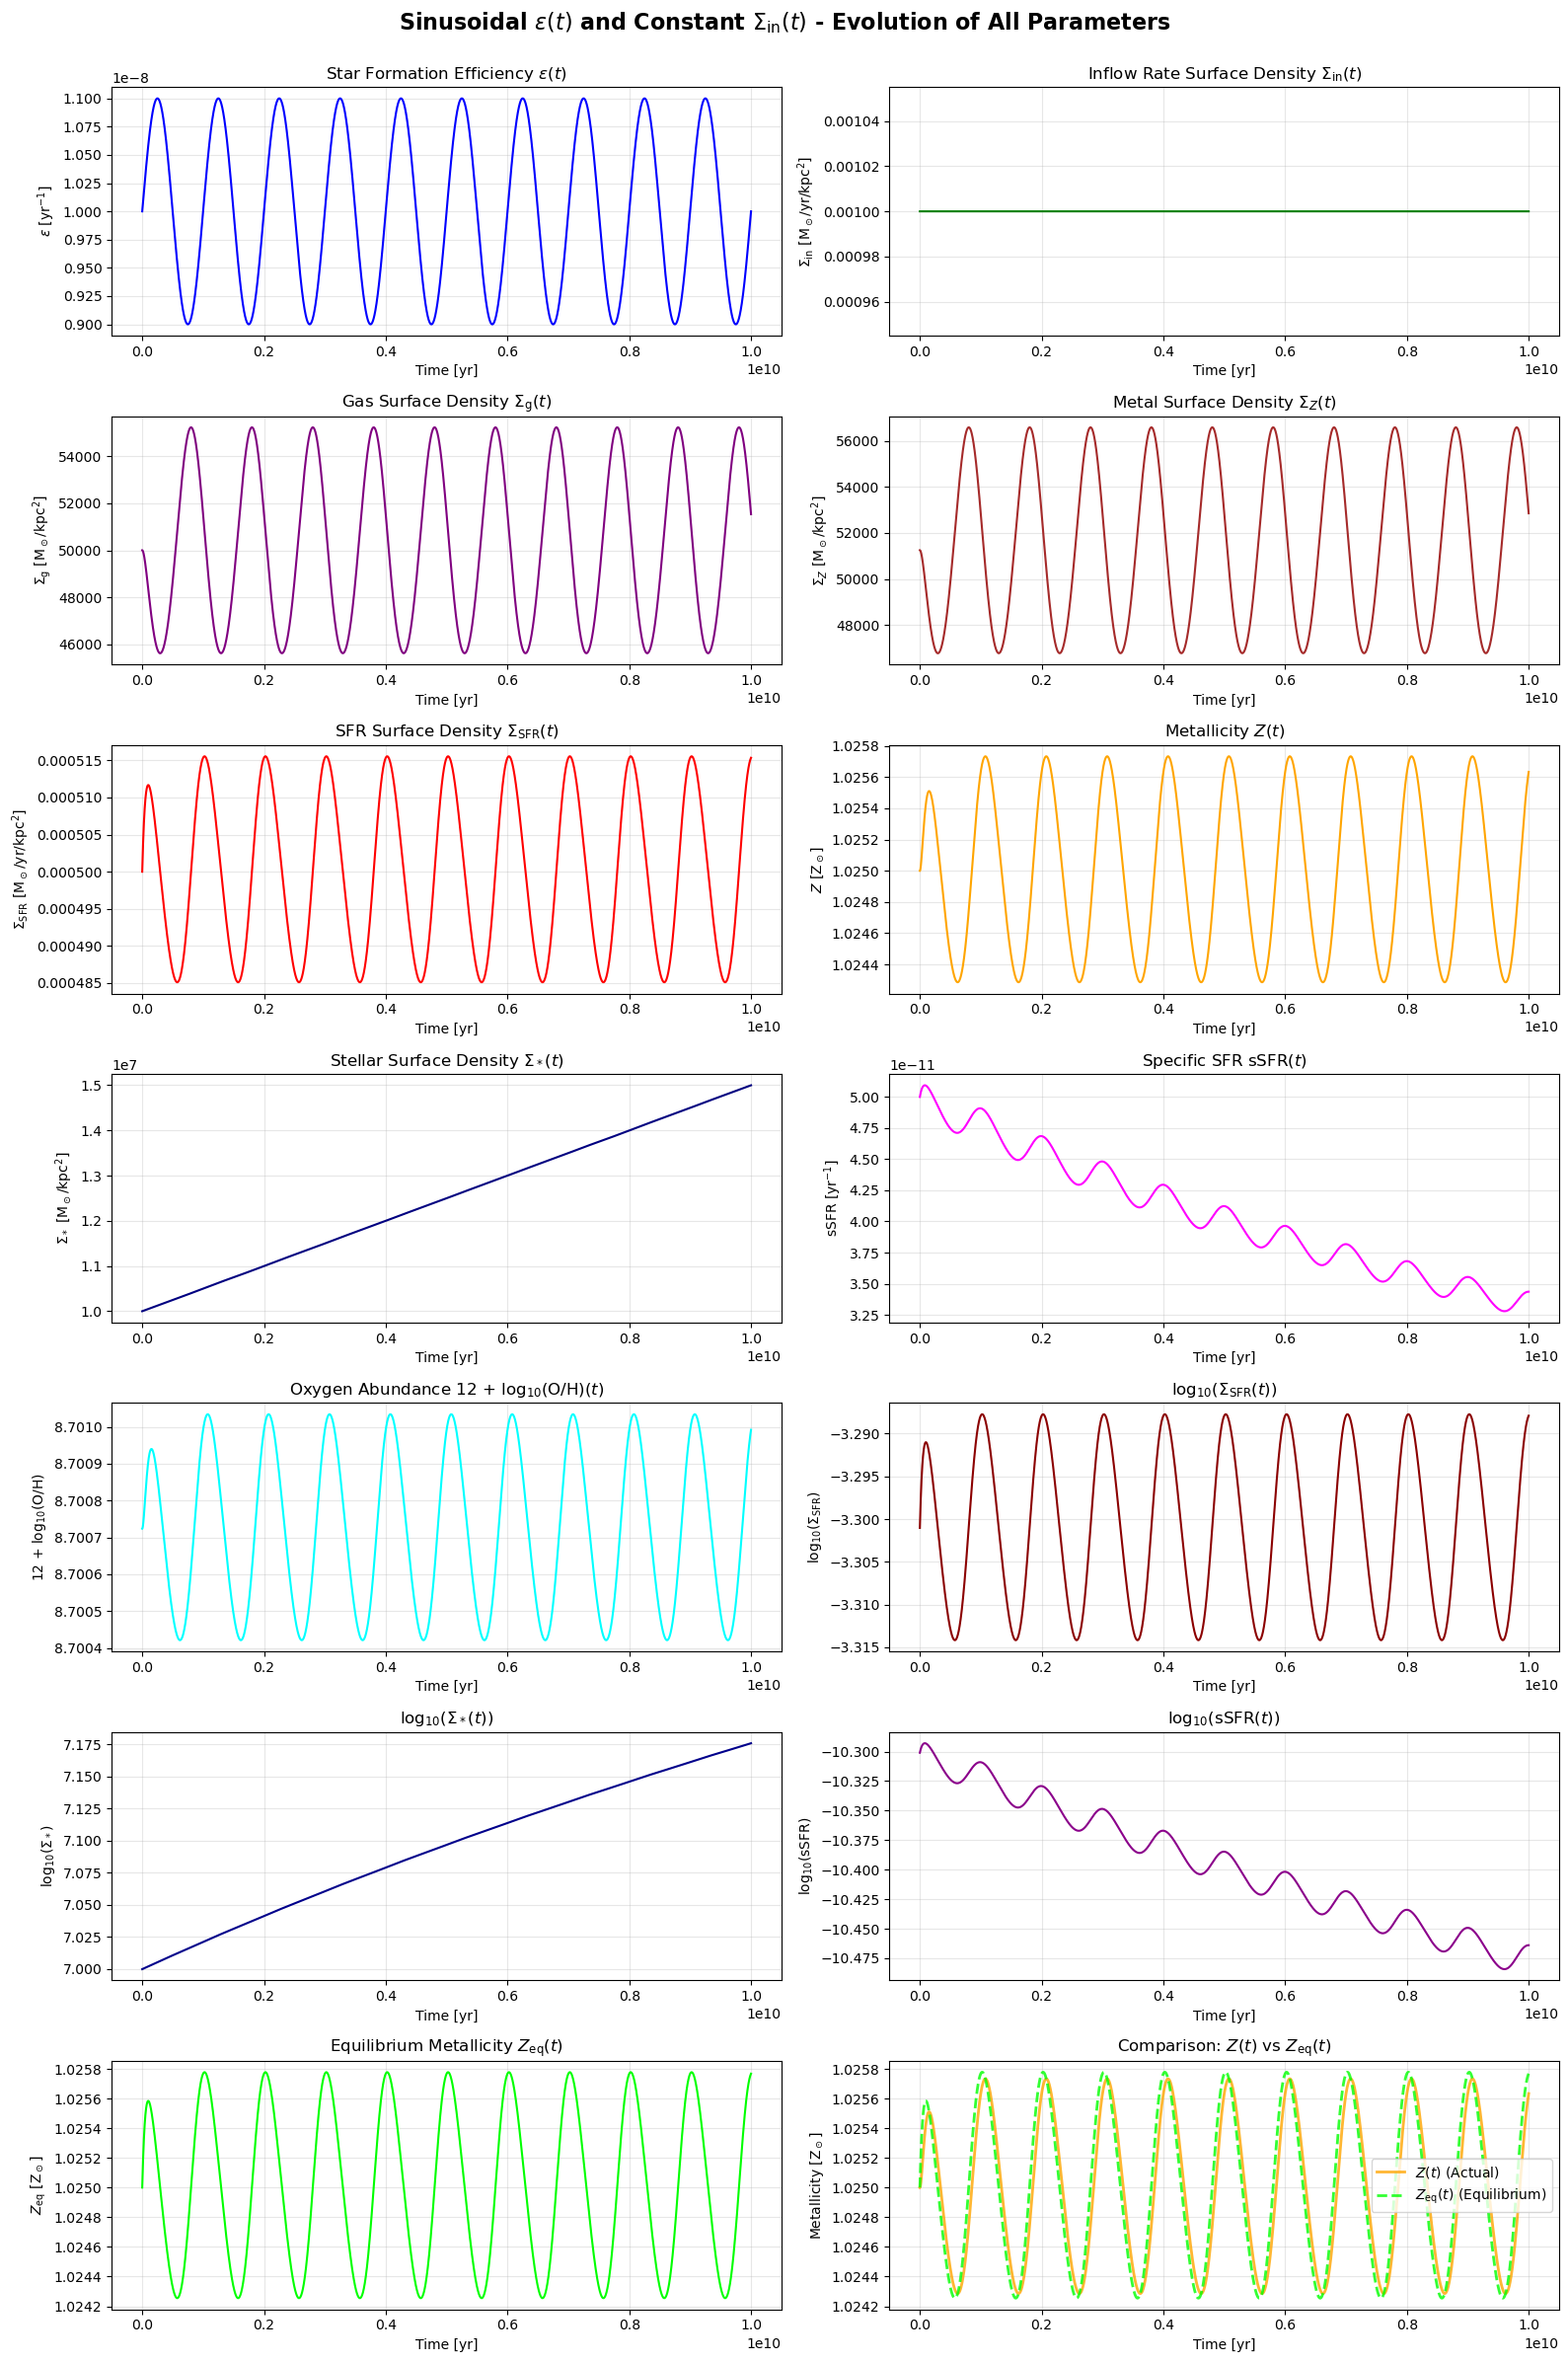


Summary of Case 4.2 evolution:
  Initial Z = 1.025000 Z_sol
  Final Z = 1.025633 Z_sol
  Initial Z_eq = 1.025000 Z_sol
  Final Z_eq = 1.025768 Z_sol
  Z converges to Z_eq: True


In [33]:
## Visualization of all 13 parameters evolution for Case that sinusoidal epsilon and constant Sigma_in

# Create figure with 14 subplots (7 rows x 2 columns)
fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

# Use the sin_epsilon_const_Sigma_in arrays
t = t_array_sin_epsilon_const_Sigma_in
epsilon = epsilon_array_sin_epsilon_const_Sigma_in
Sigma_in = Sigma_in_array_sin_epsilon_const_Sigma_in
Sigma_g = Sigma_g_array_sin_epsilon_const_Sigma_in
Sigma_Z = Sigma_Z_array_sin_epsilon_const_Sigma_in
Sigma_SFR = Sigma_SFR_array_sin_epsilon_const_Sigma_in
Z = Z_array_sin_epsilon_const_Sigma_in
Sigma_star = Sigma_star_array_sin_epsilon_const_Sigma_in
sSFR = sSFR_array_sin_epsilon_const_Sigma_in
OH = OH_array_sin_epsilon_const_Sigma_in
log10_Sigma_SFR = log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in
log10_Sigma_star = log10_Sigma_star_array_sin_epsilon_const_Sigma_in
log10_sSFR = log10_sSFR_array_sin_epsilon_const_Sigma_in
Z_eq = Z_eq_array_sin_epsilon_const_Sigma_in

# 1. epsilon[t]
axes[0].plot(t, epsilon, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t, Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t, Sigma_g, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t, Sigma_Z, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t, Sigma_SFR, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t, Z, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t, Sigma_star, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t, sSFR, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t, OH, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t, log10_Sigma_SFR, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t, log10_Sigma_star, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t, log10_sSFR, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# 13. Z_eq[t]
axes[12].plot(t, Z_eq, 'lime', linewidth=1.5)
axes[12].set_xlabel('Time [yr]')
axes[12].set_ylabel(r'$Z_{\rm eq}$ [Z$_\odot$]')
axes[12].set_title(r'Equilibrium Metallicity $Z_{\rm eq}(t)$')
axes[12].grid(True, alpha=0.3)

# 14. Z[t] vs Z_eq[t] comparison
axes[13].plot(t, Z, 'orange', linewidth=2, label=r'$Z(t)$ (Actual)', alpha=0.8)
axes[13].plot(t, Z_eq, 'lime', linewidth=2, label=r'$Z_{\rm eq}(t)$ (Equilibrium)', alpha=0.8, linestyle='--')
axes[13].set_xlabel('Time [yr]')
axes[13].set_ylabel(r'Metallicity [Z$_\odot$]')
axes[13].set_title(r'Comparison: $Z(t)$ vs $Z_{\rm eq}(t)$')
axes[13].legend(loc='best')
axes[13].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Sinusoidal $\\epsilon(t)$ and Constant $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 4.2 evolution:")
print(f"  Initial Z = {Z[0]:.6f} Z_sol")
print(f"  Final Z = {Z[-1]:.6f} Z_sol")
print(f"  Initial Z_eq = {Z_eq[0]:.6f} Z_sol")
print(f"  Final Z_eq = {Z_eq[-1]:.6f} Z_sol")
print(f"  Z converges to Z_eq: {np.abs(Z[-1] - Z_eq[-1]) < 0.001}")

In [34]:
epsilon_array_sin_epsilon_const_Sigma_in, Sigma_in_array_const_epsilon_sin_Sigma_in

(array([1.00000000e-08, 1.00006283e-08, 1.00012566e-08, ...,
        9.99874336e-09, 9.99937168e-09, 1.00000000e-08], shape=(100001,)),
 array([0.001     , 0.00100006, 0.00100013, ..., 0.00099987, 0.00099994,
        0.001     ], shape=(100001,)))

In [35]:
Z_array_sin_epsilon_const_Sigma_in

array([1.025     , 1.025     , 1.025     , ..., 1.02563296, 1.02563322,
       1.02563348], shape=(100001,))

In [36]:
OH_array_sin_epsilon_const_Sigma_in

array([8.70072387, 8.70072387, 8.70072387, ..., 8.70099197, 8.70099208,
       8.70099219], shape=(100001,))

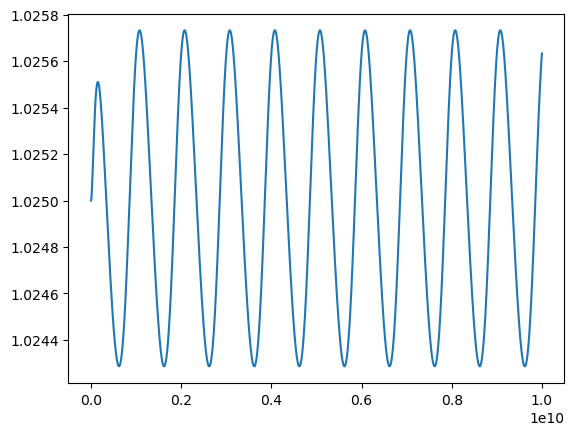

In [37]:
plt.plot(t,Z)

In [38]:
t

array([0.0000e+00, 1.0000e+05, 2.0000e+05, ..., 9.9998e+09, 9.9999e+09,
       1.0000e+10], shape=(100001,))

In [39]:
Z

array([1.025     , 1.025     , 1.025     , ..., 1.02563296, 1.02563322,
       1.02563348], shape=(100001,))

In [40]:
OH

array([8.70072387, 8.70072387, 8.70072387, ..., 8.70099197, 8.70099208,
       8.70099219], shape=(100001,))

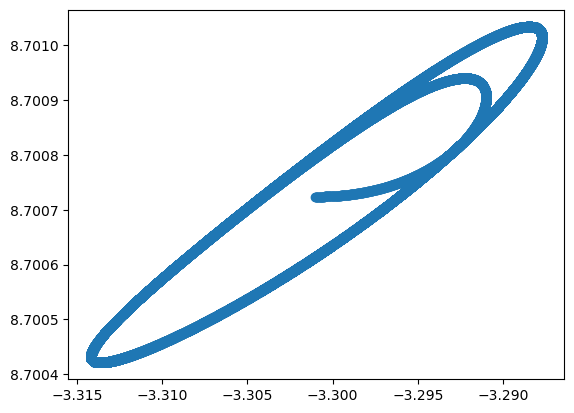

In [41]:
plt.plot(log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in, OH_array_sin_epsilon_const_Sigma_in, 'o')

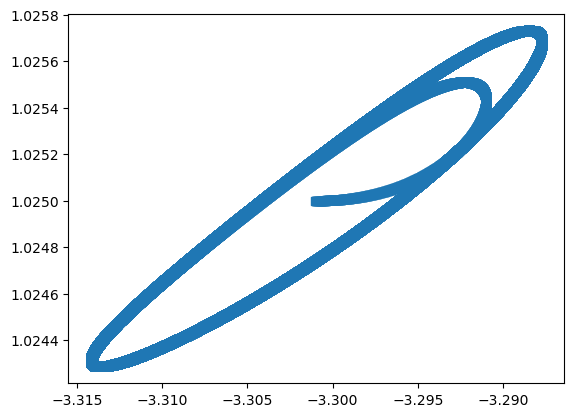

In [42]:
plt.scatter(log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in, Z_array_sin_epsilon_const_Sigma_in,marker=',')

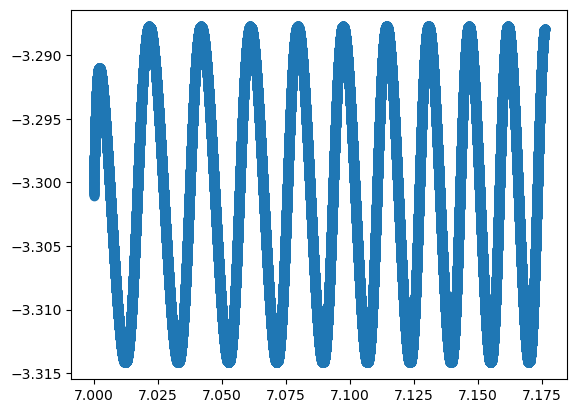

In [43]:
plt.plot(log10_Sigma_star_array_sin_epsilon_const_Sigma_in, log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in, 'o')

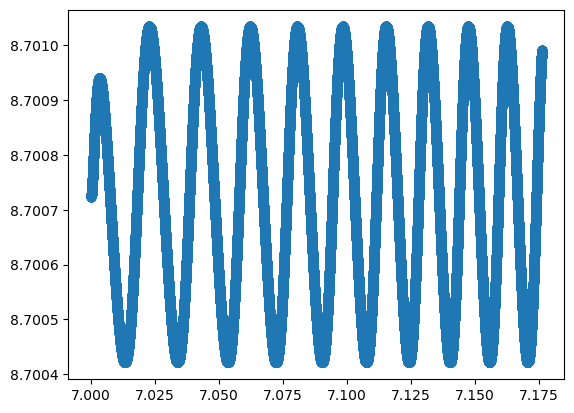

In [44]:
plt.plot(log10_Sigma_star_array_sin_epsilon_const_Sigma_in, OH_array_sin_epsilon_const_Sigma_in, 'o')

Found 21 intersection points between Z(t) and Z_eq(t)

Intersection details:
----------------------------------------------------------------------
Intersection 1:
  Time: 0.00 yr
  Metallicity: 1.025000 Z_sol
  Between indices [0, 1]: t=[0.00, 100000.00] yr
  Z crosses Z_eq from above to below

Intersection 2:
  Time: 151605125.41 yr
  Metallicity: 1.025511 Z_sol
  Between indices [1516, 1517]: t=[151600000.00, 151700000.00] yr
  Z crosses Z_eq from below to above

Intersection 3:
  Time: 620439909.84 yr
  Metallicity: 1.024286 Z_sol
  Between indices [6204, 6205]: t=[620400000.00, 620500000.00] yr
  Z crosses Z_eq from above to below

Intersection 4:
  Time: 1076310995.97 yr
  Metallicity: 1.025733 Z_sol
  Between indices [10763, 10764]: t=[1076300000.00, 1076400000.00] yr
  Z crosses Z_eq from below to above

Intersection 5:
  Time: 1620455786.16 yr
  Metallicity: 1.024286 Z_sol
  Between indices [16204, 16205]: t=[1620400000.00, 1620500000.00] yr
  Z crosses Z_eq from above to belo

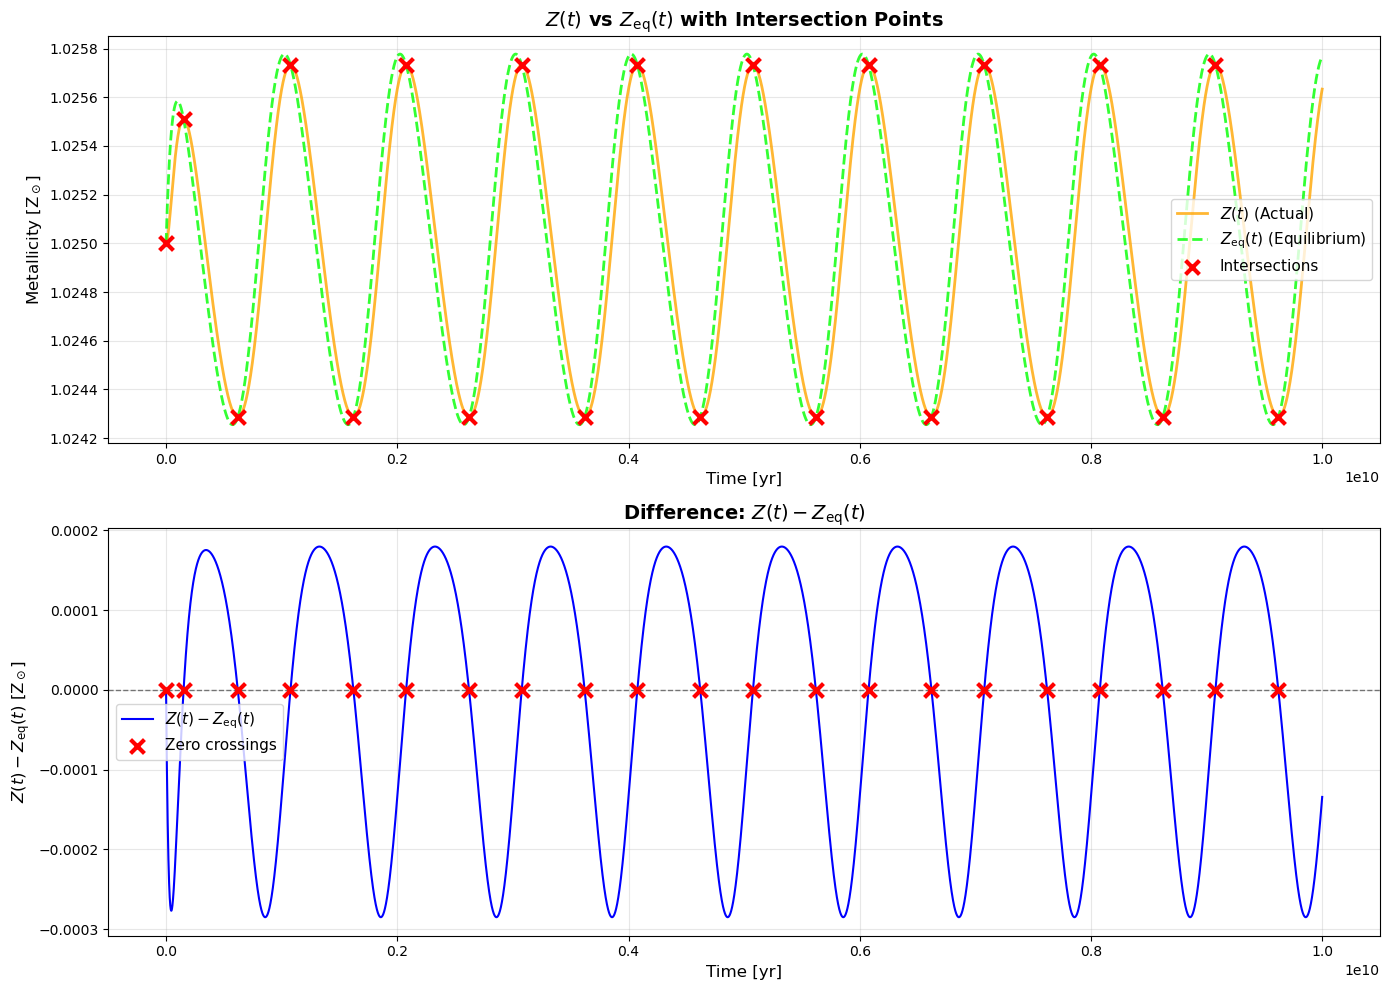


Summary: Found 21 intersections over 10000000000.0 yr
Average period between intersections: 481022789.31 yr
Expected period (T_p): 1000000000.0 yr


In [45]:
## Find intersections between Z and Z_eq for discrete points
# Using Case 4.2: sin_epsilon_const_Sigma_in

t = t_array_sin_epsilon_const_Sigma_in
Z = Z_array_sin_epsilon_const_Sigma_in
Z_eq = Z_eq_array_sin_epsilon_const_Sigma_in

# Calculate the difference Z - Z_eq
diff = Z - Z_eq

# Find sign changes (where intersection occurs)
# A sign change means diff[i] and diff[i+1] have opposite signs
sign_changes = np.where(np.diff(np.sign(diff)))[0]

print(f"Found {len(sign_changes)} intersection points between Z(t) and Z_eq(t)")
print("\nIntersection details:")
print("-" * 70)

intersection_times = []
intersection_Z_values = []

for idx in sign_changes:
    # Linear interpolation to find more precise intersection time
    t1, t2 = t[idx], t[idx+1]
    Z1, Z2 = Z[idx], Z[idx+1]
    Z_eq1, Z_eq2 = Z_eq[idx], Z_eq[idx+1]
    diff1, diff2 = diff[idx], diff[idx+1]
    
    # Linear interpolation: t_intersect = t1 - diff1 * (t2-t1)/(diff2-diff1)
    if diff2 != diff1:
        t_intersect = t1 - diff1 * (t2 - t1) / (diff2 - diff1)
        # Interpolate Z value at intersection
        Z_intersect = Z1 + (Z2 - Z1) * (t_intersect - t1) / (t2 - t1)
    else:
        t_intersect = (t1 + t2) / 2
        Z_intersect = (Z1 + Z2) / 2
    
    intersection_times.append(t_intersect)
    intersection_Z_values.append(Z_intersect)
    
    print(f"Intersection {len(intersection_times)}:")
    print(f"  Time: {t_intersect:.2f} yr")
    print(f"  Metallicity: {Z_intersect:.6f} Z_sol")
    print(f"  Between indices [{idx}, {idx+1}]: t=[{t1:.2f}, {t2:.2f}] yr")
    print(f"  Z crosses Z_eq from {'below' if diff1 < 0 else 'above'} to {'below' if diff2 < 0 else 'above'}")
    print()

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: Z and Z_eq with intersection points
axes[0].plot(t, Z, 'orange', linewidth=2, label=r'$Z(t)$ (Actual)', alpha=0.8)
axes[0].plot(t, Z_eq, 'lime', linewidth=2, label=r'$Z_{\rm eq}(t)$ (Equilibrium)', alpha=0.8, linestyle='--')
if len(intersection_times) > 0:
    axes[0].scatter(intersection_times, intersection_Z_values, color='red', s=100, 
                   zorder=5, label='Intersections', marker='x', linewidths=3)
axes[0].set_xlabel('Time [yr]', fontsize=12)
axes[0].set_ylabel(r'Metallicity [Z$_\odot$]', fontsize=12)
axes[0].set_title(r'$Z(t)$ vs $Z_{\rm eq}(t)$ with Intersection Points', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bottom panel: Difference (Z - Z_eq) to show sign changes
axes[1].plot(t, diff, 'b-', linewidth=1.5, label=r'$Z(t) - Z_{\rm eq}(t)$')
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
if len(intersection_times) > 0:
    axes[1].scatter(intersection_times, np.zeros_like(intersection_times), 
                   color='red', s=100, zorder=5, label='Zero crossings', marker='x', linewidths=3)
axes[1].set_xlabel('Time [yr]', fontsize=12)
axes[1].set_ylabel(r'$Z(t) - Z_{\rm eq}(t)$ [Z$_\odot$]', fontsize=12)
axes[1].set_title(r'Difference: $Z(t) - Z_{\rm eq}(t)$', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"Summary: Found {len(intersection_times)} intersections over {T} yr")
if len(intersection_times) > 1:
    periods = np.diff(intersection_times)
    print(f"Average period between intersections: {np.mean(periods):.2f} yr")
    print(f"Expected period (T_p): {T_p} yr")


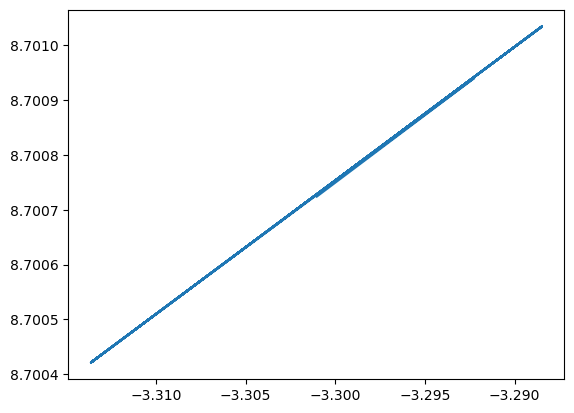

In [46]:
plt.plot(log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in_eq, OH_array_sin_epsilon_const_Sigma_in_eq)

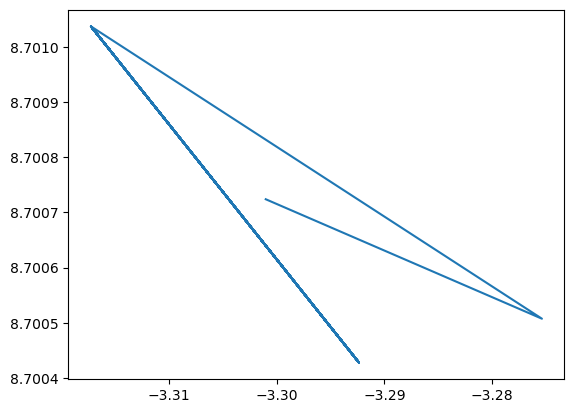

In [47]:
plt.plot(log10_Sigma_SFR_array_const_epsilon_sin_Sigma_in_eq, OH_array_const_epsilon_sin_Sigma_in_eq)

Found 21 intersection points between Z(t) and Z_eq(t)

Intersection details:
----------------------------------------------------------------------
Intersection 1:
  Time: 0.00 yr
  Metallicity: 1.025000 Z_sol
  Between indices [0, 1]: t=[0.00, 100000.00] yr
  Z crosses Z_eq from above to above

Intersection 2:
  Time: 155922714.68 yr
  Metallicity: 1.024489 Z_sol
  Between indices [1559, 1560]: t=[155900000.00, 156000000.00] yr
  Z crosses Z_eq from above to below

Intersection 3:
  Time: 611281968.04 yr
  Metallicity: 1.025739 Z_sol
  Between indices [6112, 6113]: t=[611200000.00, 611300000.00] yr
  Z crosses Z_eq from below to above

Intersection 4:
  Time: 1082292683.94 yr
  Metallicity: 1.024302 Z_sol
  Between indices [10822, 10823]: t=[1082200000.00, 1082300000.00] yr
  Z crosses Z_eq from above to below

Intersection 5:
  Time: 1611309659.28 yr
  Metallicity: 1.025739 Z_sol
  Between indices [16113, 16114]: t=[1611300000.00, 1611400000.00] yr
  Z crosses Z_eq from below to abov

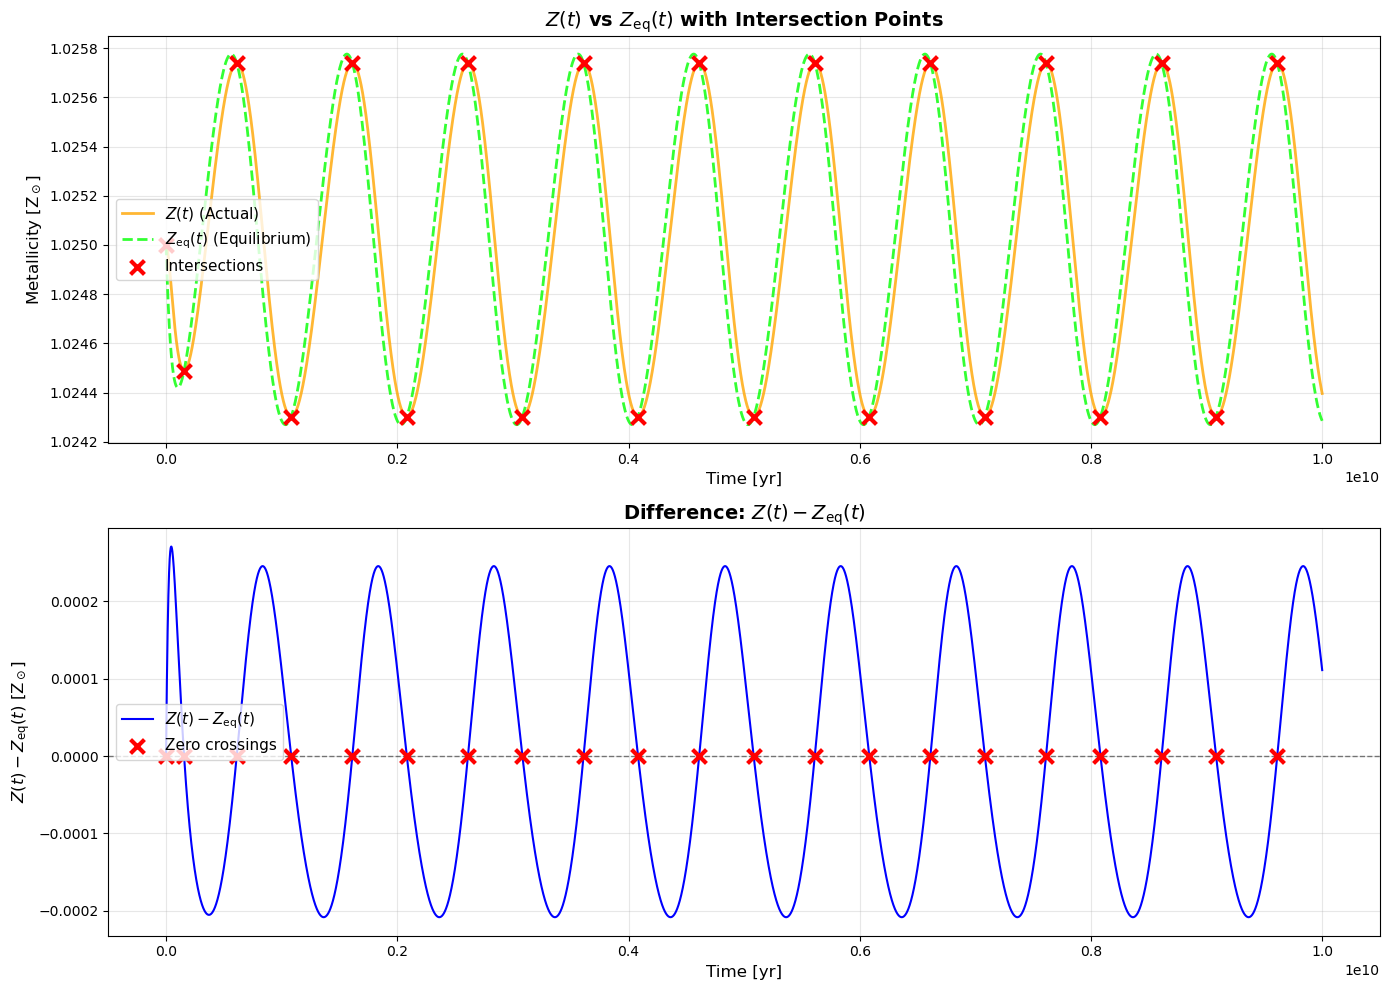


Summary: Found 21 intersections over 10000000000.0 yr
Average period between intersections: 480565482.96 yr
Expected period (T_p): 1000000000.0 yr


In [48]:
## Find intersections between Z and Z_eq for discrete points
# Using Case 4.3: const_epsilon_sin_Sigma_in

t = t_array_const_epsilon_sin_Sigma_in
Z = Z_array_const_epsilon_sin_Sigma_in
Z_eq = Z_eq_array_const_epsilon_sin_Sigma_in

# Calculate the difference Z - Z_eq
diff = Z - Z_eq

# Find sign changes (where intersection occurs)
# A sign change means diff[i] and diff[i+1] have opposite signs
sign_changes = np.where(np.diff(np.sign(diff)))[0]

print(f"Found {len(sign_changes)} intersection points between Z(t) and Z_eq(t)")
print("\nIntersection details:")
print("-" * 70)

intersection_times = []
intersection_Z_values = []

for idx in sign_changes:
    # Linear interpolation to find more precise intersection time
    t1, t2 = t[idx], t[idx+1]
    Z1, Z2 = Z[idx], Z[idx+1]
    Z_eq1, Z_eq2 = Z_eq[idx], Z_eq[idx+1]
    diff1, diff2 = diff[idx], diff[idx+1]
    
    # Linear interpolation: t_intersect = t1 - diff1 * (t2-t1)/(diff2-diff1)
    if diff2 != diff1:
        t_intersect = t1 - diff1 * (t2 - t1) / (diff2 - diff1)
        # Interpolate Z value at intersection
        Z_intersect = Z1 + (Z2 - Z1) * (t_intersect - t1) / (t2 - t1)
    else:
        t_intersect = (t1 + t2) / 2
        Z_intersect = (Z1 + Z2) / 2
    
    intersection_times.append(t_intersect)
    intersection_Z_values.append(Z_intersect)
    
    print(f"Intersection {len(intersection_times)}:")
    print(f"  Time: {t_intersect:.2f} yr")
    print(f"  Metallicity: {Z_intersect:.6f} Z_sol")
    print(f"  Between indices [{idx}, {idx+1}]: t=[{t1:.2f}, {t2:.2f}] yr")
    print(f"  Z crosses Z_eq from {'below' if diff1 < 0 else 'above'} to {'below' if diff2 < 0 else 'above'}")
    print()

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: Z and Z_eq with intersection points
axes[0].plot(t, Z, 'orange', linewidth=2, label=r'$Z(t)$ (Actual)', alpha=0.8)
axes[0].plot(t, Z_eq, 'lime', linewidth=2, label=r'$Z_{\rm eq}(t)$ (Equilibrium)', alpha=0.8, linestyle='--')
if len(intersection_times) > 0:
    axes[0].scatter(intersection_times, intersection_Z_values, color='red', s=100, 
                   zorder=5, label='Intersections', marker='x', linewidths=3)
axes[0].set_xlabel('Time [yr]', fontsize=12)
axes[0].set_ylabel(r'Metallicity [Z$_\odot$]', fontsize=12)
axes[0].set_title(r'$Z(t)$ vs $Z_{\rm eq}(t)$ with Intersection Points', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bottom panel: Difference (Z - Z_eq) to show sign changes
axes[1].plot(t, diff, 'b-', linewidth=1.5, label=r'$Z(t) - Z_{\rm eq}(t)$')
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
if len(intersection_times) > 0:
    axes[1].scatter(intersection_times, np.zeros_like(intersection_times), 
                   color='red', s=100, zorder=5, label='Zero crossings', marker='x', linewidths=3)
axes[1].set_xlabel('Time [yr]', fontsize=12)
axes[1].set_ylabel(r'$Z(t) - Z_{\rm eq}(t)$ [Z$_\odot$]', fontsize=12)
axes[1].set_title(r'Difference: $Z(t) - Z_{\rm eq}(t)$', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"Summary: Found {len(intersection_times)} intersections over {T} yr")
if len(intersection_times) > 1:
    periods = np.diff(intersection_times)
    print(f"Average period between intersections: {np.mean(periods):.2f} yr")
    print(f"Expected period (T_p): {T_p} yr")
